<a href="https://colab.research.google.com/github/gien-7/progetto_GraphColouring_ML26/blob/main/Notebook_GNN_v1.0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [423]:
import os

repo_name = 'progetto_GraphColouring_ML26'
repo_url = 'https://github.com/gien-7/progetto_GraphColouring_ML26.git'

if not os.path.exists(repo_name):
    !git clone {repo_url}
else:
    print(f"La cartella '{repo_name}' è già caricata")

La cartella 'progetto_GraphColouring_ML26' è già caricata


In [424]:
from torch.utils.data import TensorDataset, Dataset, DataLoader
import torch
import torch.utils.data as data

#!pip install torch_geometric

In [425]:
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

In [426]:
seed = 42

#Preprocessing

In [427]:
import pandas as pd

file1 = 'progetto_GraphColouring_ML26/g6.col'  # queen9x9
file2 = 'progetto_GraphColouring_ML26/g17.col'  # miles750

df_g6 = pd.read_csv(file1, sep='\s+', skiprows=4, usecols=[1,2], names=['node1','node2'])
df_g17 = pd.read_csv(file2, sep='\s+', skiprows=4, usecols=[1,2], names=['node1','node2'])

print('Shape g6.col  : ',df_g6.shape)
print('Shape g17.col : ',df_g17.shape)

Shape g6.col  :  (2112, 2)
Shape g17.col :  (4226, 2)


##queen9x9

In [428]:
print(df_g6)

      node1  node2
0         1     11
1         1     21
2         1     31
3         1     41
4         1     51
...     ...    ...
2107     81     21
2108     81     18
2109     81     11
2110     81      9
2111     81      1

[2112 rows x 2 columns]


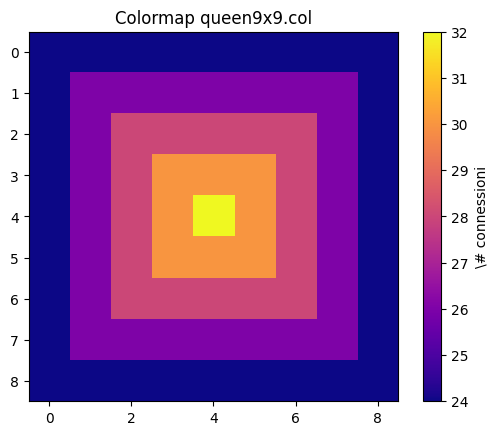

In [429]:
import numpy as np
import matplotlib.pyplot as plt

unique, counts = np.unique(df_g6['node1'].values, return_counts=True)  # non cambierebbe nulla se operassi invece su node2 per simmetria
queen_intensity = counts.reshape(9,9)

plt.imshow(queen_intensity, cmap='plasma')
plt.colorbar(label = '\# connessioni')
plt.title('Colormap queen9x9.col')
plt.show()

In [430]:
index_grid = (unique-1).reshape(9,9)
index_grid

array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8],
       [ 9, 10, 11, 12, 13, 14, 15, 16, 17],
       [18, 19, 20, 21, 22, 23, 24, 25, 26],
       [27, 28, 29, 30, 31, 32, 33, 34, 35],
       [36, 37, 38, 39, 40, 41, 42, 43, 44],
       [45, 46, 47, 48, 49, 50, 51, 52, 53],
       [54, 55, 56, 57, 58, 59, 60, 61, 62],
       [63, 64, 65, 66, 67, 68, 69, 70, 71],
       [72, 73, 74, 75, 76, 77, 78, 79, 80]])

**Data augmentation sfruttando invarianze per simmetria del problema**

In [431]:
def build_edges_from_df(col1, col2):
  src = torch.tensor(col1.values, dtype=torch.long)
  dst = torch.tensor(col2.values, dtype=torch.long)
  edge_index = torch.stack([src, dst], dim=0)
  return edge_index

def transform_node_index(x, y, k_rot, do_flip=False):
    if do_flip:
        x=-x
    for _ in range(k_rot):
        # Rotazione 90°: (x, y) -> (y, -x)
        x, y = y, -x
    pos_n_aug = torch.stack([x, y], dim=1)
    return pos_n_aug

def transform_edges(serie, k_rot, do_flip=False):
  idx = serie-1  # da 1->81 a 0->80
  r = idx // 9
  c = idx % 9
  if do_flip:
    c = 8 - c
  for _ in range(k_rot):
    r, c = c, 8 - r
  return (r * 9 + c) +1 #da 0->80 a 1->81

In [432]:
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data

class QueenGraphGenerator(Dataset):  # Cambiamento rispetto alla CNN: il Dataset ora produce grafi PyG, non immagini.
    def __init__(self, X, df, AUGMENT=True):
      super().__init__()
      self.X = X  # intenità nodi
      self.df = df
      self.AUGMENT = AUGMENT

    def __len__(self):  # Ritorna la dimensione del dataset
      return len(self.X)

    def __getitem__(self, idx): #ritorna l'elemento idx del dataset
      intensity = self.X[idx].copy()
      node_list = self.df[idx].copy() # copy() per evitare che augment modifichi i dati originali
      col1_label = (self.df[idx].columns)[0]
      col2_label = (self.df[idx].columns)[1]

      k_rot = 0
      do_flip = False

      rows, cols = np.indices((9, 9))
      rows = rows.reshape(-1) # [0,0,0 // 1,1,1 // ... // n,n,n]
      cols = cols.reshape(-1) # [0,1,2...,n // 0,1,2,...,n // ...]
      values = intensity[rows, cols].astype(np.float32)  # sarà unidimensionale avendo flattenato

      # data.pos contiene le coordinate geometriche non normalizzate delle connessioni sul piano 9x9.
      pos = torch.tensor(np.stack([rows, cols], axis=1), dtype=torch.float)
      pos_n = (pos/8.) * 2. - 1.

      '''
      L'augmentation ha il fine di cambiare l'ordine degli indici
      quindi magari [0][2]=(2) -> [8][6]=(79)'. Segue che, oltre a ruotare
      il tensore delle posizioni, dovrò anche cambiare i vari edges:
      la nuova posizione (79)' eredita le connessioni di (2), e viceversa per (2)'.
      D'altro canto, la feature d'intensity non varia per simmetria del problema!
      Per formalismo è stato fatto lo stesso.
      '''

      if self.AUGMENT: # solo in training!!
        k_rot = np.random.randint(0, 4)
        do_flip = np.random.choice([True, False])
        x_coords = pos_n[:, 0].clone()
        y_coords = pos_n[:, 1].clone()
        pos_n = transform_node_index(x_coords, y_coords, k_rot, do_flip)

        node_list[col1_label] = transform_edges(node_list[col1_label].values, k_rot, do_flip)
        node_list[col2_label] = transform_edges(node_list[col2_label].values, k_rot, do_flip)

      # Creo vettore x contenente
      value = torch.tensor(values/values.sum(), dtype=torch.float).view(-1, 1)
      x = torch.cat([value, pos_n], dim=1)  # torch vuole dimensione dummy delle label di x

      # L'output di build_knn_edges del tipo torch.Tensor(2, (num_nodes x k_eff)), interi int64
      edge_index = build_edges_from_df(node_list[col1_label]-1, node_list[col2_label]-1)
      # In input le due serie relative al dataframe, scalate di 1 (anzichè fare da 1->9 fa 0->8)

      # Problema unsupervised, uso y dummy pari a indici delle caselle
      tensor_label = torch.arange(81, dtype=torch.long)

      return Data(x=x, edge_index=edge_index, y=tensor_label, pos=pos_n)

In [433]:
queen_df = df_g6.copy()
N = 800  # randomizzerò 800 volte per epoca, sullo stesso grafo di partenza
multi_X = [queen_intensity] * N
multi_df = [queen_df] * N

queen_dataset = QueenGraphGenerator(multi_X, multi_df, AUGMENT=True)
queen_loader = DataLoader(queen_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)

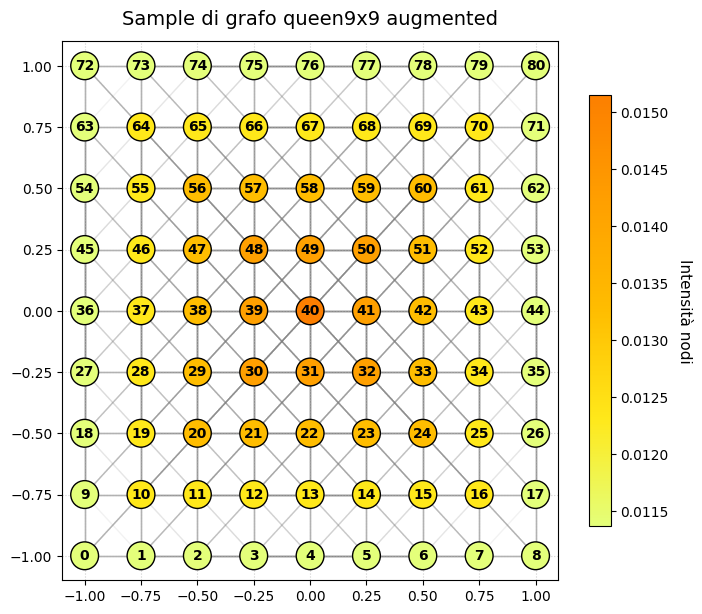

In [444]:
from torch_geometric.utils import to_networkx
import networkx as nx

data = queen_dataset[0]
G = to_networkx(data, to_undirected=True)
pos_dict = {i: data.pos[i].numpy() for i in range(data.num_nodes)}

fig, ax = plt.subplots(figsize=(8, 7))

nodes = nx.draw_networkx_nodes(G, pos_dict,
                               ax=ax,
                               node_size=400,
                               node_color=data.x[:, 0].numpy(),
                               cmap='Wistia',
                               edgecolors='black')

nx.draw_networkx_edges(G, pos_dict, ax=ax, alpha=0.1, edge_color='gray')
nx.draw_networkx_labels(G, pos_dict, ax=ax,
                        font_size=10,
                        font_family='sans-serif',
                        font_weight='bold')

cbar = fig.colorbar(nodes, shrink = 0.8, ax=ax)
cbar.set_label('Intensità nodi', rotation=270, labelpad=17, fontsize=11)

ax.set_axis_on()
ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)

x_coords = data.pos[:, 0].numpy()
y_coords = data.pos[:, 1].numpy()
ax.set_xlim(x_coords.min() - 0.1, x_coords.max() + 0.1)
ax.set_ylim(y_coords.min() - 0.1, y_coords.max() + 0.1)

ax.grid(True, linestyle=':', alpha=0.6)
ax.set_title("Sample di grafo queen9x9 augmented", fontsize=14, pad=12)

plt.show()

##miles750

In [435]:
print(df_g17)

      node1  node2
0         1    128
1         1    122
2         1    120
3         1    119
4         1    117
...     ...    ...
4221    128     14
4222    128      8
4223    128      7
4224    128      2
4225    128      1

[4226 rows x 2 columns]


In [436]:
unique, counts = np.unique(df_g17['node1'].values, return_counts=True)  # non cambierebbe nulla se operassi invece su node2 per simmetria
miles_intensity = counts.astype(np.float32)

In [437]:
G = nx.Graph()
G.add_edges_from(zip(df_g17['node1'], df_g17['node2']))

pos = nx.spring_layout(G, seed=seed)

In [438]:
import collections

od = collections.OrderedDict(sorted(pos.items()))  #ordina dizionario dalle keys
od_keys = []
od_vals = []
for k, v in od.items():
  od_keys.append(k)1  od_vals.append(v)

od_vals = np.array(od_vals)
#od_keys è in struttura uguale a unique

In [439]:
class MilesGraphGenerator(Dataset):
    def __init__(self, X, df, coords, AUGMENT=True):
        self.X = X
        self.df = df
        self.coords = coords
        self.AUGMENT = AUGMENT

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        intensity = self.X.copy()
        node_list = self.df.copy()
        coords_sim = self.coords.copy()
        col1_label = (self.df.columns)[0]
        col2_label = (self.df.columns)[1]

        edge_index_raw = build_edges_from_df(node_list[col1_label]-1, node_list[col2_label]-1)
        num_nodes = len(intensity)

        '''
        Augmentation con stessa filosofia di queen9x9, ma adesso non voglio ruotare
        secondo il gruppo di simmetria: essendo i nodi liberi, ovvero non dipendenti
        dalle posizioni ma dalle connessioni, mi concentro sul generalizzare il grafo
        permutando, con l'obiettivo di non incorrere in minimi come prima.
        '''

        if self.AUGMENT:
            perm = torch.randperm(num_nodes)  # rimescolamento degli indici
            intensity = intensity[perm]
            coords_sim = coords_sim[perm]
            #Rimappo gli archi affinché puntino ai nuovi indici
            reverse_perm = torch.empty_like(perm)
            reverse_perm[perm] = torch.arange(num_nodes)
            edge_index = reverse_perm[edge_index_raw]
        else:
            edge_index = edge_index_raw

        pos = torch.tensor(coords_sim, dtype=torch.float)
        p_min, p_max = pos.min(), pos.max()
        pos_n = ((pos - p_min) / (p_max - p_min + 1e-7)) * 2. - 1.

        val_t = torch.tensor(intensity / (intensity.sum() + 1e-7), dtype=torch.float).view(-1, 1)

        x = torch.cat([val_t, pos_n], dim=1)

        tensor_label = torch.arange(81, dtype=torch.long)

        return Data(x=x, edge_index=edge_index, y=tensor_label, pos=pos_n)

In [440]:
miles_df = df_g17.copy()
N = 800  # randomizzerò 800 volte per epoca, sullo stesso grafo di partenza
multi_X = [miles_intensity] * N
multi_df = [miles_df] * N
multi_od_vals = [od_vals] * N

miles_dataset = MilesGraphGenerator(miles_intensity, miles_df, od_vals, AUGMENT=True)
miles_loader = DataLoader(miles_dataset, batch_size=32, shuffle=True)

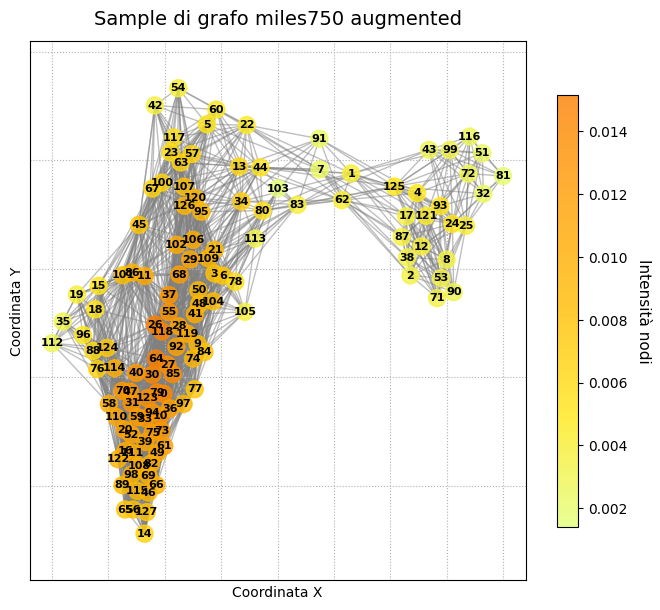

In [446]:
data = miles_dataset[0]
G = to_networkx(data, to_undirected=True)
pos_dict = {i: data.pos[i].numpy() for i in range(128)}

fig, ax = plt.subplots(figsize=(8, 7))

nodes = nx.draw_networkx_nodes(
    G, pos_dict,
    ax=ax,
    node_size=150,
    node_color=data.x[:, 0].numpy(),
    cmap='Wistia',
    alpha=0.8
)

nx.draw_networkx_edges(G, pos_dict, ax=ax, alpha=0.5, edge_color="gray")
nx.draw_networkx_labels(G, pos_dict, ax=ax, font_size=8, font_weight='bold')

cbar = fig.colorbar(nodes, shrink = 0.8, ax=ax)
cbar.set_label('Intensità nodi', rotation=270, labelpad=17, fontsize=11)

x_coords = data.pos[:, 0].numpy()
ax.set_xlim(x_coords.min() - 0.1, x_coords.max() + 0.1)
ax.grid(True, linestyle=':', alpha=1.0)

ax.set_title("Sample di grafo miles750 augmented", fontsize=14, pad=12)
ax.set_xlabel("Coordinata X", fontsize=10)
ax.set_ylabel("Coordinata Y", fontsize=10)

plt.show()

In [442]:
#N.B.: da configurare cuda
#N.B. 2: lo splitting non serve siccome non devo generalizzare